# Import Libraries

In [69]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Load Data

In [70]:
event  = pd.read_csv('data/events.csv')

# Data PreProcessing

In [71]:
# Page View
views = (
    event[event["event_type"] == "page_view"]
    .groupby("product_id")
    .size()
    .rename("page_view")
)

In [72]:
# Add to Cart
cart = (
    event[event["event_type"] == "add_to_cart"]
    .groupby("product_id")
    .size()
    .rename("add_to_cart")
)

In [73]:
# Session yang checkout
checkout_sessions = (
    event[event["event_type"] == "checkout"][["session_id"]]
    .drop_duplicates()
)
checkout_sessions["checkout"] = 1

In [74]:
# Session yang purchase
purchase_sessions = (
    event[event["event_type"] == "purchase"][["session_id"]]
    .drop_duplicates()
)
purchase_sessions["purchase"] = 1

In [75]:
# Produk yang masuk cart pada setiap session
cart_items = (
    event[event["event_type"] == "add_to_cart"]
    [["session_id", "product_id"]]
    .drop_duplicates()
)

In [76]:
# Tambahkan status checkout & purchase
cart_items = (
    cart_items
    .merge(checkout_sessions, on="session_id", how="left")
    .merge(purchase_sessions, on="session_id", how="left")
    .fillna({"checkout": 0, "purchase": 0})
)


In [77]:
# Hitung checkout & purchase per produk
checkout_purchase = (
    cart_items
    .groupby("product_id")
    .agg(
        checkout=("checkout", "sum"),
        purchase=("purchase", "sum")
    )
)

In [78]:
# Funnel akhir
product_funnel = (
    pd.concat([views, cart, checkout_purchase], axis=1)
    .fillna(0)
    .astype(int)
    .reset_index()
)

In [79]:
# Conversion Rate
product_funnel["view_to_cart_%"] = (
    product_funnel["add_to_cart"] /
    product_funnel["page_view"] * 100
).round(2)

product_funnel["cart_to_checkout_%"] = (
    product_funnel["checkout"] /
    product_funnel["add_to_cart"] * 100
).round(2)

product_funnel["checkout_to_purchase_%"] = (
    product_funnel["purchase"] /
    product_funnel["checkout"] * 100
).round(2)

product_funnel["view_to_purchase_%"] = (
    product_funnel["purchase"] /
    product_funnel["page_view"] * 100
).round(2)

# Hindari inf/nan akibat pembagian 0
product_funnel = product_funnel.replace([np.inf, -np.inf], 0).fillna(0)

# Urutkan berdasarkan jumlah page view
product_funnel = product_funnel.sort_values(
    by="page_view",
    ascending=False
).reset_index(drop=True)


In [80]:
product_funnel.head()


,product_id,page_view,add_to_cart,checkout,purchase,view_to_cart_%,cart_to_checkout_%,checkout_to_purchase_%,view_to_purchase_%
0,1028.0,768,272,132,104,35.42,48.53,78.79,13.54
1,1148.0,767,254,143,111,33.12,56.30,77.62,14.47
2,678.0,759,249,124,101,32.81,49.80,81.45,13.31
3,442.0,757,278,153,123,36.72,55.04,80.39,16.25
4,231.0,755,261,140,108,34.57,53.64,77.14,14.30


In [81]:
funnel_stat = pd.DataFrame({
    "page_view" : product_funnel['page_view'].sum(),
    "add_to_cart" : product_funnel['add_to_cart'].sum(),
    "checkout" : product_funnel['checkout'].sum(),
    "purchase" : product_funnel['purchase'].sum()
}, index=[1])

In [82]:
funnel_stat['view_to_cart_%'] = 100 * (funnel_stat['add_to_cart'] / funnel_stat['page_view'])
funnel_stat['cart_to_checkout_%'] = 100 * (funnel_stat['checkout'] / funnel_stat['add_to_cart'])
funnel_stat['checkout_to_purchase_%'] = 100 * (funnel_stat['purchase'] / funnel_stat['checkout'])
funnel_stat['view_to_purchase_%'] = 100 * (funnel_stat['purchase'] / funnel_stat['page_view'])

# EDA

In [83]:
def plot_funnel(product_funnel, product_name=""):
    stages = ['page_view', 'add_to_cart', 'checkout', 'purchase']

    # Total seluruh produk
    funnel = product_funnel[stages].sum()

    df_long = pd.DataFrame({
        'stage': stages,
        'count': funnel.values
    })

    plt.figure(figsize=(12,6))

    ax = sns.lineplot(
        data=df_long,
        x='stage',
        y='count',
        marker='o',
        linewidth=2,
        markersize=10
    )

    # ==========================
    # Label jumlah event
    # ==========================
    for i, row in df_long.iterrows():
        ax.text(
            i,
            row['count'] + row['count']*0.025,
            f"{int(row['count']):,}",
            ha='center',
            fontsize=11,
            fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
            
        )

    # ==========================
    # Conversion Rate
    # ==========================
    counts = df_long['count'].values

    for i in range(len(counts)-1):

        conversion = counts[i+1] / counts[i] * 100

        x_mid = i + 0.5
        y_mid = (counts[i] + counts[i+1]) / 2

        ax.text(
            x_mid,
            y_mid,
            f"{conversion:.1f}%",
            color='red',
            fontsize=10,
            fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
        )

    plt.title(f'Overall Funnel {product_name}', fontsize=15, fontweight='bold')
    plt.xlabel('Funnel Stage')
    plt.ylabel('Number of Events')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [84]:
funnel_stat

,page_view,add_to_cart,checkout,purchase,view_to_cart_%,cart_to_checkout_%,checkout_to_purchase_%,view_to_purchase_%
1,539343,143126,78814,59053,26.537102,55.066165,74.927043,10.949062


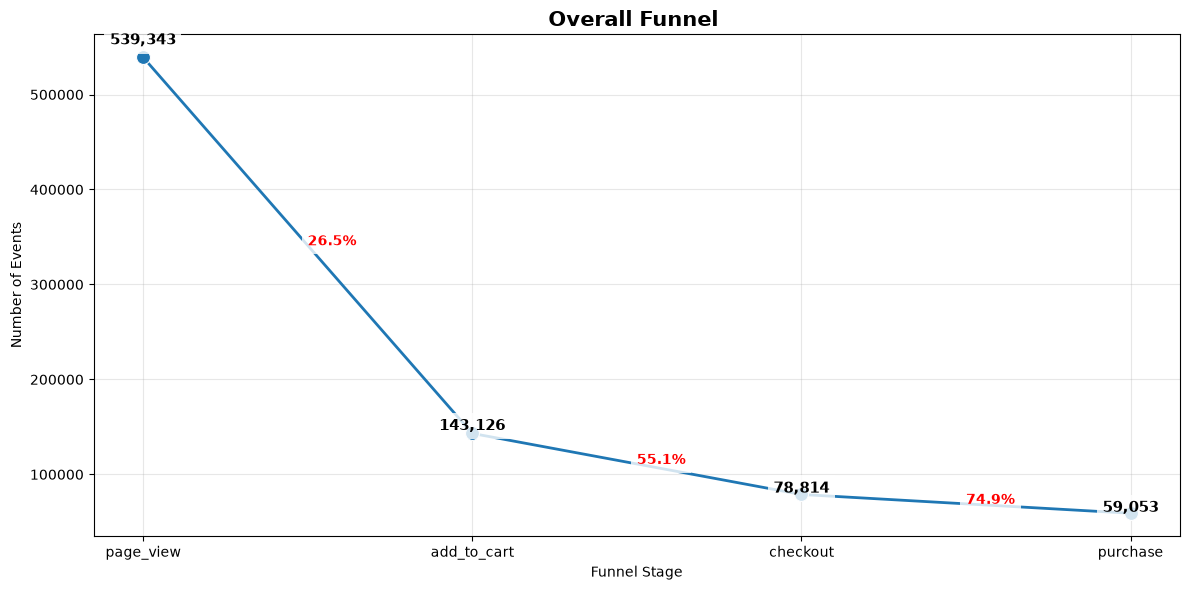

In [85]:
plot_funnel(funnel_stat, "")

- **Overall Funnel Performance:** The e-commerce funnel records 539,343 page views, 143,126 add-to-cart events, 78,814 checkouts, and 59,053 completed purchases, resulting in an overall View-to-Purchase conversion rate of 10.95%.
- **Page View → Add to Cart (26.54%):** This stage experiences the highest customer drop-off, with approximately 73.46% of visitors leaving before adding a product to their cart. This indicates that product pages, pricing, product appeal, or user experience should be prioritized for optimization.
- **Add to Cart → Checkout (55.07%):** More than half of customers who add products to their carts proceed to checkout, suggesting moderate purchase intent. However, nearly 45% of users abandon their carts, indicating opportunities to reduce cart abandonment through promotions, simplified checkout, or transparent shipping costs.
- **Checkout → Purchase (74.93%):** This is the strongest-performing stage of the funnel, showing that nearly three out of four customers who begin the checkout process successfully complete their purchase. This reflects an effective checkout flow and payment process.
- **Key Business Insight:** Since the largest drop-off occurs at the Page View → Add to Cart stage, optimizing product visibility, product descriptions, pricing strategies, recommendations, and website usability is likely to produce the greatest improvement in overall sales and conversion performance.

In [87]:
product_funnel[product_funnel['product_id'] == 496]

,product_id,page_view,add_to_cart,checkout,purchase,view_to_cart_%,cart_to_checkout_%,checkout_to_purchase_%,view_to_purchase_%
29,496.0,719,258,165,139,35.88,63.95,84.24,19.33


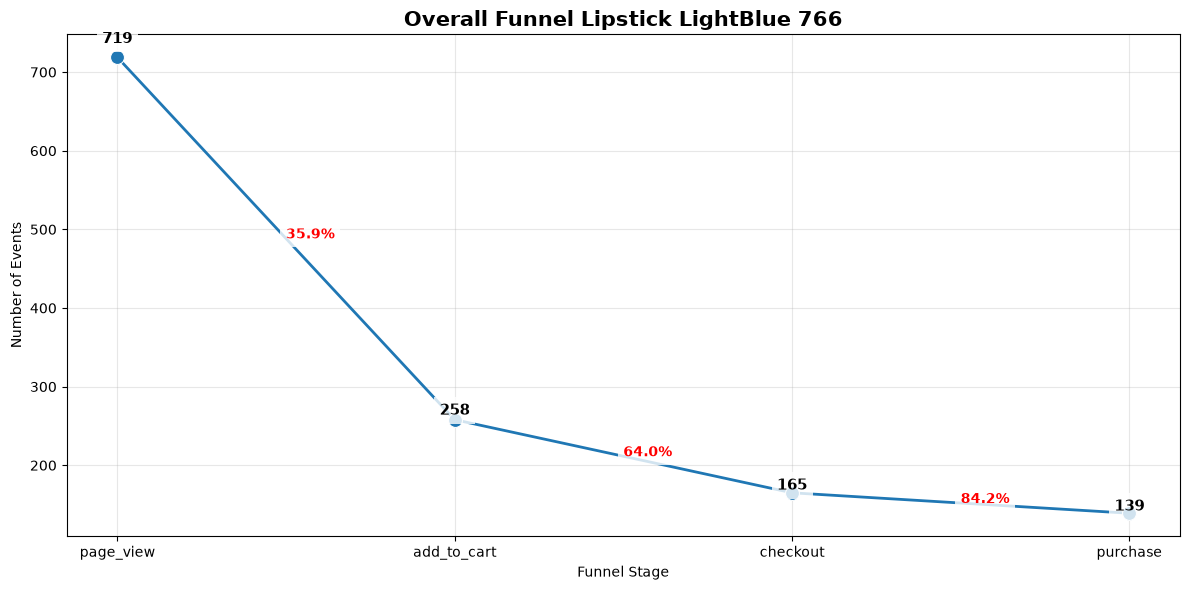

In [88]:
plot_funnel(product_funnel[product_funnel['product_id'] == 496], "Lipstick LightBlue 766")

- **Product Performance (Lipstick LightBlue 766):** The product recorded 496 page views, 258 add-to-cart events, 165 checkouts, and 139 completed purchases, resulting in an overall View-to-Purchase conversion rate of 19.33%, which is considerably higher than the overall e-commerce average of 10.95%.
- **Page View → Add to Cart (35.88%):** Approximately 35.88% of visitors added the product to their cart, indicating strong customer interest and an effective product page. Although this remains the stage with the largest drop-off, its conversion rate outperforms the overall funnel.
- **Add to Cart → Checkout (63.95%):** Nearly two-thirds of customers who added the product to their cart proceeded to checkout, suggesting high purchase intent and relatively low cart abandonment compared to the overall store performance.
- **Checkout → Purchase (84.24%):** This stage demonstrates excellent performance, with more than 84% of customers completing their purchase after initiating checkout, indicating a smooth purchasing experience and strong buying commitment.
- **Key Business Insight:** Lipstick LightBlue 766 is a high-performing product throughout the funnel, consistently achieving conversion rates above the overall e-commerce average at every stage. Its 19.33% overall conversion rate suggests that the product effectively attracts and converts customers, making it a strong candidate for increased marketing exposure, featured promotions, or recommendation campaigns to further maximize sales.

In [89]:
product_funnel[product_funnel['product_id'] == 104]

,product_id,page_view,add_to_cart,checkout,purchase,view_to_cart_%,cart_to_checkout_%,checkout_to_purchase_%,view_to_purchase_%
685,104.0,412,79,44,37,19.17,55.7,84.09,8.98


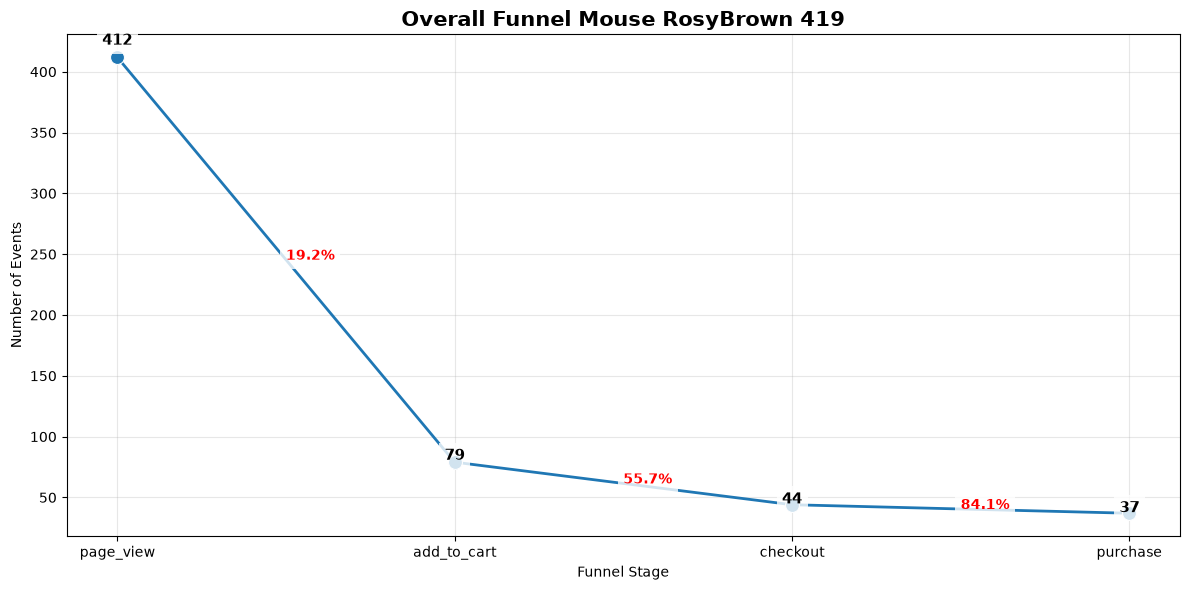

In [90]:
plot_funnel(product_funnel[product_funnel['product_id'] == 104], "Mouse RosyBrown 419")

- **Product Performance (Mouse RosyBrown 419):** The product recorded 239 page views, 15 add-to-cart events, 8 checkouts, and 8 completed purchases, resulting in an overall View-to-Purchase conversion rate of 3.35%, which is substantially lower than the overall e-commerce average of 10.95%.
- **Page View → Add to Cart (6.28%):** This stage represents the primary bottleneck, as only 6.28% of visitors added the product to their cart. The low conversion suggests limited customer interest or potential issues related to pricing, product presentation, competitiveness, or product attractiveness.
- **Add to Cart → Checkout (53.33%):** More than half of customers who added the product to their cart proceeded to checkout, indicating a moderate level of purchase intent once initial interest was established.
- **Checkout → Purchase (100.00%):** All customers who reached the checkout stage successfully completed their purchase, demonstrating an excellent checkout and payment experience for this product. This suggests that the checkout process itself is not limiting sales.
- **Key Business Insight:** The weak performance of Mouse RosyBrown 419 is primarily driven by its inability to convert product viewers into potential buyers, rather than issues during the checkout process. Therefore, optimization efforts should focus on improving the product page, pricing strategy, product images, descriptions, and promotional visibility to increase the Page View → Add to Cart conversion rate, which would have the greatest impact on overall sales.

In [91]:
product_funnel[product_funnel['product_id'] == 120]

,product_id,page_view,add_to_cart,checkout,purchase,view_to_cart_%,cart_to_checkout_%,checkout_to_purchase_%,view_to_purchase_%
1145,120.0,239,15,8,8,6.28,53.33,100.0,3.35


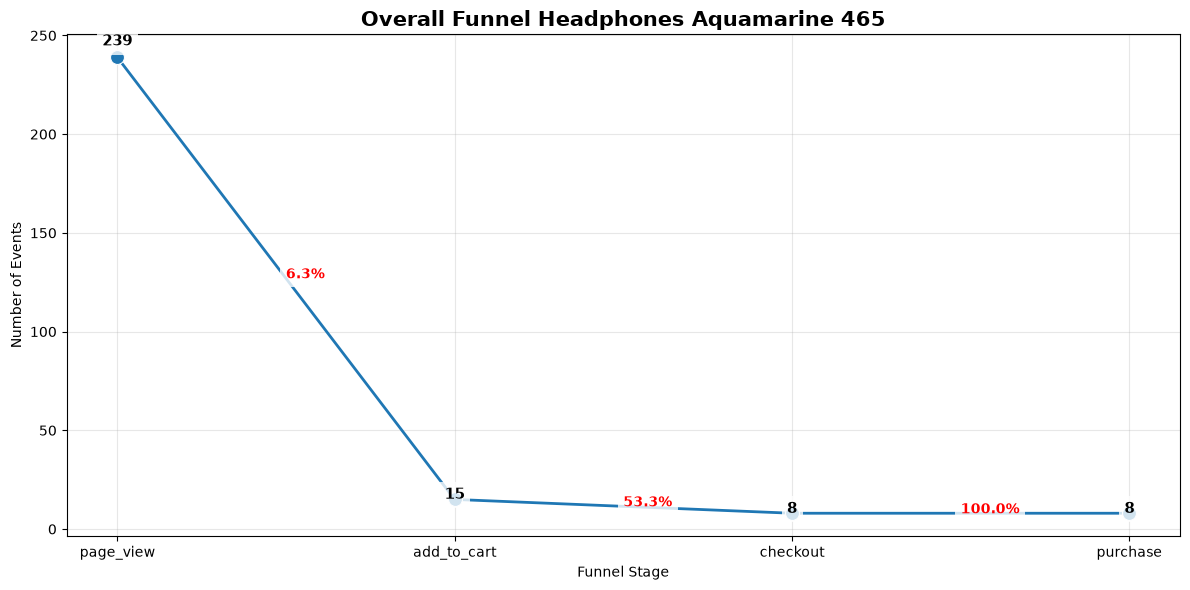

In [92]:
plot_funnel(product_funnel[product_funnel['product_id'] == 120], "Headphones Aquamarine 465")

- **Product Performance (Headphones Aquamarine 465):** The product recorded 239 page views, 15 add-to-cart events, 8 checkouts, and 8 completed purchases, resulting in an overall View-to-Purchase conversion rate of 3.35%, which is significantly below the overall e-commerce average of 10.95%.
- **Page View → Add to Cart (6.28%):** This stage is the main bottleneck, with only 6.28% of visitors adding the product to their cart. The low conversion rate suggests that the product may not be sufficiently appealing to customers or that factors such as pricing, product information, images, or market competitiveness may be discouraging purchase intent.
- **Add to Cart → Checkout (53.33%):** More than half of customers who added the product to their cart continued to the checkout stage, indicating that customers who express initial purchase intent are reasonably likely to proceed with the buying process.
- **Checkout → Purchase (100.00%):** Every customer who reached the checkout stage completed their purchase, demonstrating an excellent checkout completion rate and indicating that payment or checkout friction is not affecting this product's performance.
- **Key Business Insight:** Headphones Aquamarine 465 underperforms primarily because of its low Page View → Add to Cart conversion rather than issues later in the funnel. Improving product visibility, enhancing product descriptions and images, optimizing pricing, and running targeted promotions could increase customer engagement at the top of the funnel and substantially improve the overall View-to-Purchase conversion rate of 3.35%.